<a href="https://colab.research.google.com/github/alex-smith-uwec/CS491/blob/main/Inauguration_TF_IDF_Scikit_Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install sklearn

Import necessary modules and libraries

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd


#### Set Directory Path

Below we're setting the directory filepath that contains all the text files that we want to analyze.

In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
my_path="/content/drive/MyDrive/CS491NLP/Data/US_Inaugural_Addresses/"

In [59]:
file_names=!ls {my_path}
file_names=sorted(file_names)
#print(file_names)

In [63]:
#file_names

In [64]:
# Split combined string by tabs and newlines, then filter out any empty strings
combined_string = ' '.join(file_names)
file_list = [name.strip() for name in combined_string.split() if name.strip() and '.' in name]

# Remove the extension from each file name
text_titles = sorted([name.split('.')[0] for name in file_list])



In [65]:
text_titles[-5:]

['58_trump_2017',
 '59_biden_2021',
 '60_trump_2025',
 '61_obama_2029',
 '62_swift_2033']

In [66]:
import glob
text_files=glob.glob(f"{my_path}/*.txt")
text_files=sorted(text_files)

Initialize TfidfVectorizer with desired parameters (default smoothing and normalization)

In [67]:
tfidf_vectorizer = TfidfVectorizer(input='filename', stop_words='english')

Run TfidfVectorizer on our `text_files`

In [68]:
tfidf_vector = tfidf_vectorizer.fit_transform(text_files)
#this is a sparse matrix

Make a DataFrame out of the resulting tf–idf vector, setting the "feature names" or words as columns and the titles as rows

In [69]:
tfidf_df = pd.DataFrame(tfidf_vector.toarray(), index=text_titles, columns=tfidf_vectorizer.get_feature_names_out())

Add column for document frequency aka number of times word appears in all documents

# **Document similarity**

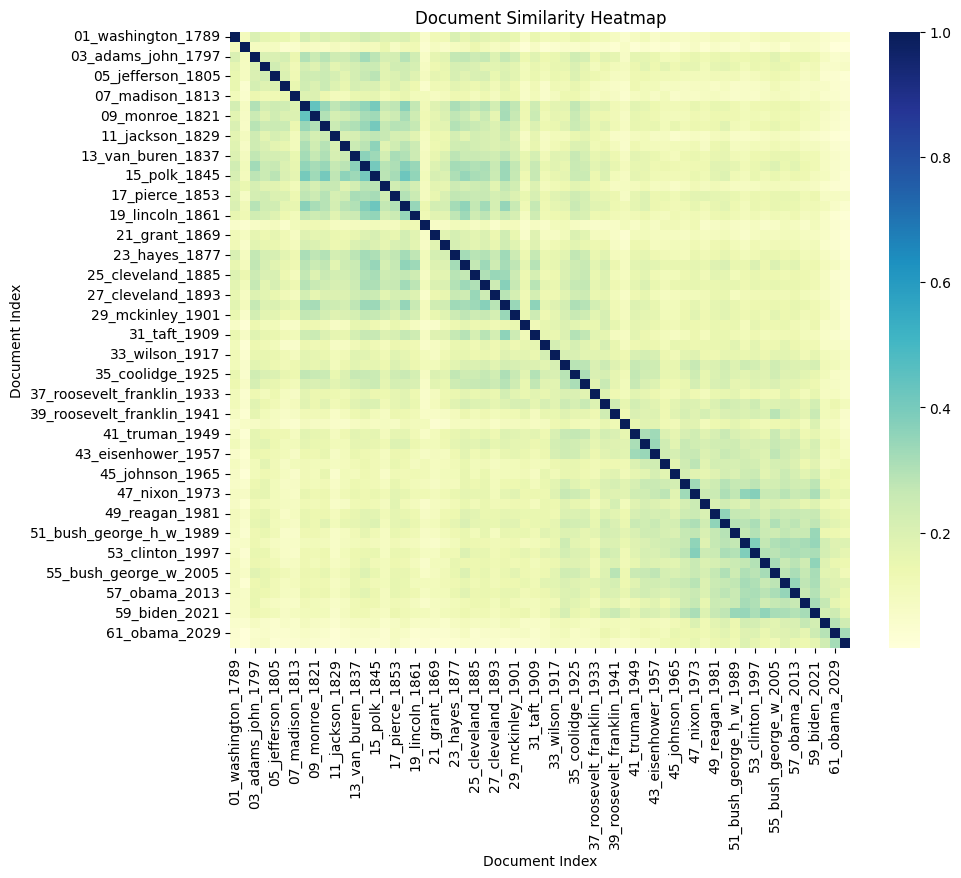

In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Compute the dot product
similarity_matrix = tfidf_df.dot(tfidf_df.T)

# Generate a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap="YlGnBu")
plt.title('Document Similarity Heatmap')
plt.xlabel('Document Index')
plt.ylabel('Document Index')
plt.show()


**The cell below will take the title of one of the speeches and return the 3 most similar speechs as determined by cosine similarity.**

In [95]:
from sklearn.metrics.pairwise import cosine_similarity

def find_most_similar_docs_by_title(tfidf_vector, target_doc_title, text_titles, top_n=3):
    # Find the index of the target document based on its title
    if target_doc_title in text_titles:
        target_doc_index = text_titles.index(target_doc_title)
    else:
        return "The document title does not exist in the corpus."

    # Calculate cosine similarity between the target document and all documents in the corpus
    cosine_similarities = cosine_similarity(tfidf_vector[target_doc_index], tfidf_vector[:-2]).flatten()

    # Get the indices of the top_n most similar documents, excluding the target document itself
    most_similar_doc_indices = cosine_similarities.argsort()[-top_n-1:-1][::-1]

    # Map indices to titles
    most_similar_doc_titles = [text_titles[i] for i in most_similar_doc_indices]

    # Return the titles of the top_n most similar documents
    return most_similar_doc_titles

# Example usage
target_doc_title = "60_trump_2025"  # Replace with your actual document title
similar_docs_titles = find_most_similar_docs_by_title(tfidf_vector, target_doc_title, text_titles)
print("Titles of 3 real speech documents that most similar the fictional speech 60_trump_2025:", similar_docs_titles)

target_doc_title = "61_obama_2029"  # Replace with your actual document title
similar_docs_titles = find_most_similar_docs_by_title(tfidf_vector, target_doc_title, text_titles)
print("Titles of 3 real speech documents that most similar the fictional speech 61_obama_2029:", similar_docs_titles)

target_doc_title = "62_swift_2033"  # Replace with your actual document title
similar_docs_titles = find_most_similar_docs_by_title(tfidf_vector, target_doc_title, text_titles)
print("Titles of 3 real speech documents that most similar the fictional speech 62_swift_2033:", similar_docs_titles)



Titles of 3 real speech documents that most similar the fictional speech 60_trump_2025: ['58_trump_2017', '59_biden_2021', '52_clinton_1993']
Titles of 3 real speech documents that most similar the fictional speech 61_obama_2029: ['59_biden_2021', '57_obama_2013', '53_clinton_1997']
Titles of 3 real speech documents that most similar the fictional speech 62_swift_2033: ['52_clinton_1993', '56_obama_2009', '59_biden_2021']
